# Spectral features and digit classification on the Free Spoken Digit Dataset

Spectral feature can also be used to *describe* and *classify* samples. The intuition behind it is that the sound of some words has different vowels and consonants, and these are (approximately) separable in the frequency domain. It's not a perfect system, but it works well for simple problems. It's also the basis behind learned solutions. Remember that even a convolution network for audio is doing frequency analysis under the hood due to the convolution theorem.

**Dataset**: [Free Spoken Digit Dataset (FSDD)](https://github.com/Jakobovski/free-spoken-digit-dataset)  
3000 WAV recordings of digits 0 to 9, 6 speakers, 50 repetitions per digit and speaker, 8 kHz. **Download it before running the notebook!**

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.io import wavfile
from scipy.signal import resample
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from IPython.display import Audio, display

# Point this to the cloned repo. Fix this if you put it in a different directory
FSDD_PATH = Path("../data/free-spoken-digit-dataset/recordings")
assert FSDD_PATH.exists(), (
    f"Dataset not found at {FSDD_PATH}. "
    "Run: git clone https://github.com/Jakobovski/free-spoken-digit-dataset"
)

TARGET_SR = 8000  # all FSDD files are 8 kHz
TARGET_LEN = 8000  # pad/trim to exactly 1 second

## Load the dataset

FSDD filenames follow the pattern `{digit}_{speaker}_{index}.wav`.

In [2]:
def load_clip(path, target_len=TARGET_LEN):
    sr, data = wavfile.read(path)
    # Convert to float in [-1, 1]
    data = data.astype(np.float32) / np.iinfo(data.dtype).max
    # Pad or trim to target_len samples
    if len(data) < target_len:
        data = np.pad(data, (0, target_len - len(data)))
    else:
        data = data[:target_len]
    return data


clips, labels, speakers = [], [], []
for wav_path in sorted(FSDD_PATH.glob("*.wav")):
    parts = wav_path.stem.split("_")
    digit, speaker = int(parts[0]), parts[1]
    clips.append(load_clip(wav_path))
    labels.append(digit)
    speakers.append(speaker)

clips = np.array(clips)  # (N, TARGET_LEN)
labels = np.array(labels)  # (N,)
speakers = np.array(speakers)

print(
    f"Loaded {len(clips)} clips,  digits: {sorted(set(labels))},  speakers: {sorted(set(speakers))}"
)
print(f"Clips per digit: {[(d, (labels == d).sum()) for d in range(10)]}")

Loaded 3000 clips,  digits: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)],  speakers: [np.str_('george'), np.str_('jackson'), np.str_('lucas'), np.str_('nicolas'), np.str_('theo'), np.str_('yweweler')]
Clips per digit: [(0, np.int64(300)), (1, np.int64(300)), (2, np.int64(300)), (3, np.int64(300)), (4, np.int64(300)), (5, np.int64(300)), (6, np.int64(300)), (7, np.int64(300)), (8, np.int64(300)), (9, np.int64(300))]


## Data visualization

Listen to one recording per digit, then look at the waveforms side-by-side.
Even before computing anything, you can see that some digits are much shorter, some have sharp transients (sibilants), others are smoother.

In [3]:
# Play one example per digit (first occurrence)
for digit in range(10):
    idx = np.where(labels == digit)[0][0]
    print(f"Digit {digit}:")
    display(Audio(clips[idx], rate=TARGET_SR))

Digit 0:


Digit 1:


Digit 2:


Digit 3:


Digit 4:


Digit 5:


Digit 6:


Digit 7:


Digit 8:


Digit 9:


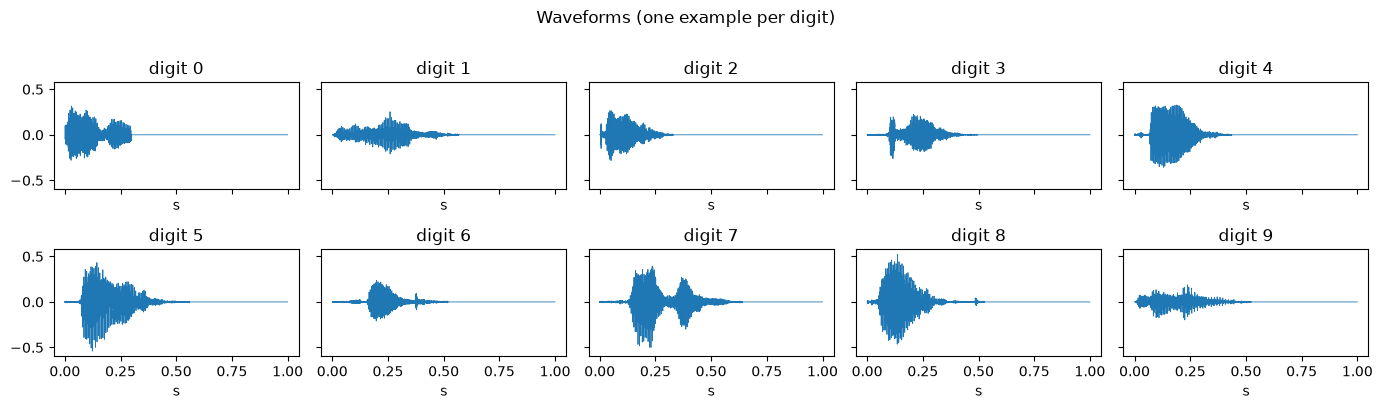

In [4]:
t = np.arange(TARGET_LEN) / TARGET_SR

fig, axes = plt.subplots(2, 5, figsize=(14, 4), sharey=True, sharex=True)
for digit, ax in enumerate(axes.ravel()):
    idx = np.where(labels == digit)[0][0]
    ax.plot(t, clips[idx], lw=0.6)
    ax.set_title(f"digit {digit}")
    ax.set_xlabel("s")
plt.suptitle("Waveforms (one example per digit)", y=1.01)
plt.tight_layout()
plt.show()

## Visualize FFT

We compute the FFT of one clip per digit. Notice how digits have different spectra.

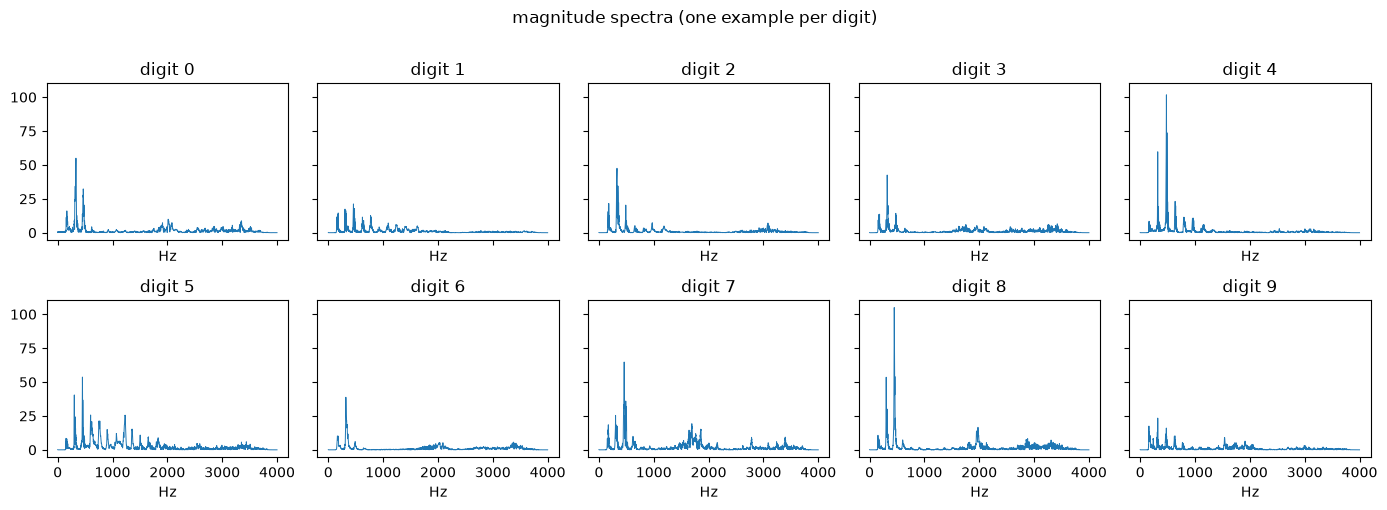

In [5]:
freqs = np.fft.rfftfreq(TARGET_LEN, d=1 / TARGET_SR)

fig, axes = plt.subplots(2, 5, figsize=(14, 5), sharey=True, sharex=True)
for digit, ax in enumerate(axes.ravel()):
    idx = np.where(labels == digit)[0][0]
    mag = np.abs(np.fft.rfft(clips[idx]))
    ax.plot(freqs, mag + 1e-6, lw=0.7)
    ax.set_title(f"digit {digit}")
    ax.set_xlabel("Hz")
plt.suptitle("magnitude spectra (one example per digit)", y=1.01)
plt.tight_layout()
plt.show()

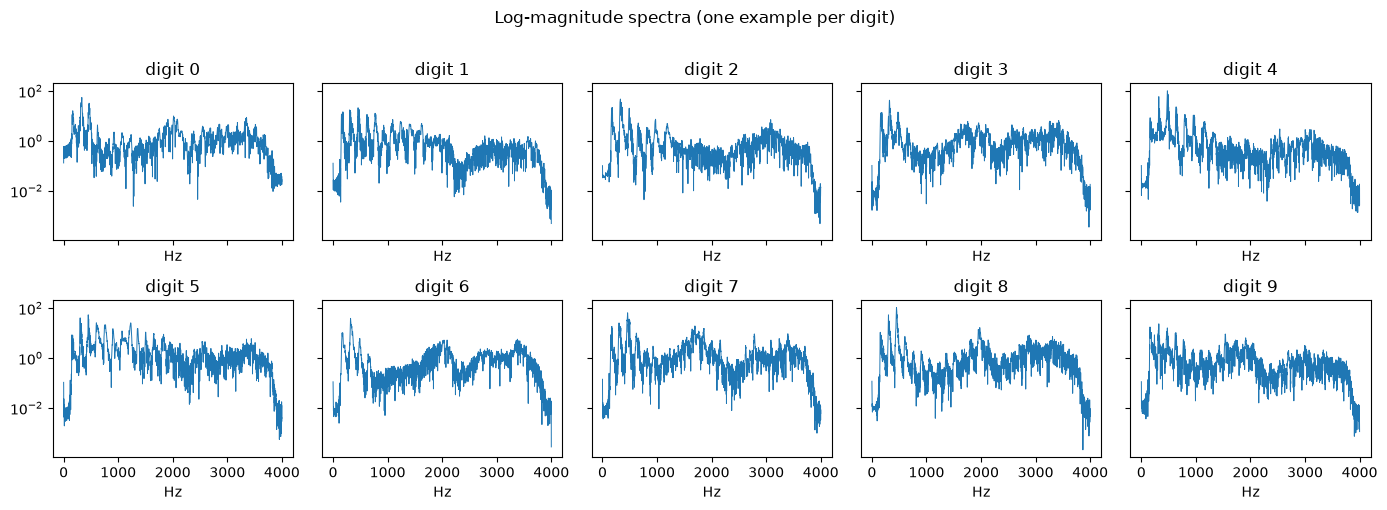

In [6]:
freqs = np.fft.rfftfreq(TARGET_LEN, d=1 / TARGET_SR)

fig, axes = plt.subplots(2, 5, figsize=(14, 5), sharey=True, sharex=True)
for digit, ax in enumerate(axes.ravel()):
    idx = np.where(labels == digit)[0][0]
    mag = np.abs(np.fft.rfft(clips[idx]))
    ax.semilogy(freqs, mag + 1e-6, lw=0.7)
    ax.set_title(f"digit {digit}")
    ax.set_xlabel("Hz")
plt.suptitle("Log-magnitude spectra (one example per digit)", y=1.01)
plt.tight_layout()
plt.show()

## Spectral feature extraction

Instead of using the full spectrum as input (4001 numbers per clip), we can extract some standard features:

- **Spectral centroid**: "Centre of mass" of the spectrum
- **Spectral rolloff**: Frequency below which 85% of the energy lies
- **Zero-crossing rate**: How often the signal changes sign

These are all measure of "brightness" / high-frequency content.

In [7]:
def spectral_centroid(x, sr):
    """Compute the spectral centroid of a signal x sampled at sr Hz."""
    mag = np.abs(np.fft.rfft(x))  # magnitude spectrum
    f = np.fft.rfftfreq(len(x), d=1 / sr)  # corresponding frequencies
    # Weighted average of frequencies, weighted by magnitude
    return np.sum(f * mag) / (np.sum(mag) + 1e-8)


def spectral_rolloff(x, sr, threshold=0.85):
    """Compute the spectral rolloff frequency of a signal x sampled at sr Hz."""
    mag = np.abs(np.fft.rfft(x))  # magnitude spectrum
    f = np.fft.rfftfreq(len(x), d=1 / sr)  # corresponding frequencies
    cumulative = np.cumsum(mag)  # cumulative sum of magnitudes
    idx = np.searchsorted(
        cumulative, threshold * cumulative[-1]
    )  # find index where cumulative exceeds threshold
    return f[min(idx, len(f) - 1)]


def zero_crossing_rate(x):
    """Compute the zero-crossing rate of a signal x."""
    # Count how many times the signal changes sign (crosses zero)
    return np.mean(np.abs(np.diff(np.sign(x))) / 2)


# Extract features for every clip
centroids = np.array([spectral_centroid(c, TARGET_SR) for c in clips])
rolloffs = np.array([spectral_rolloff(c, TARGET_SR) for c in clips])
zcrs = np.array([zero_crossing_rate(c) for c in clips])

X = np.column_stack([centroids, rolloffs, zcrs])  # (N, 3)
print(f"Feature matrix shape: {X.shape}")
print(f"Centroid range:  {centroids.min():.0f} – {centroids.max():.0f} Hz")
print(f"Rolloff range:   {rolloffs.min():.0f} – {rolloffs.max():.0f} Hz")
print(f"ZCR range:       {zcrs.min():.3f} – {zcrs.max():.3f}")

Feature matrix shape: (3000, 3)
Centroid range:  572 – 2218 Hz
Rolloff range:   717 – 3669 Hz
ZCR range:       0.014 – 0.425


## Scatter plot of centroid vs. rolloff

Each point is one clip (colour = digit).

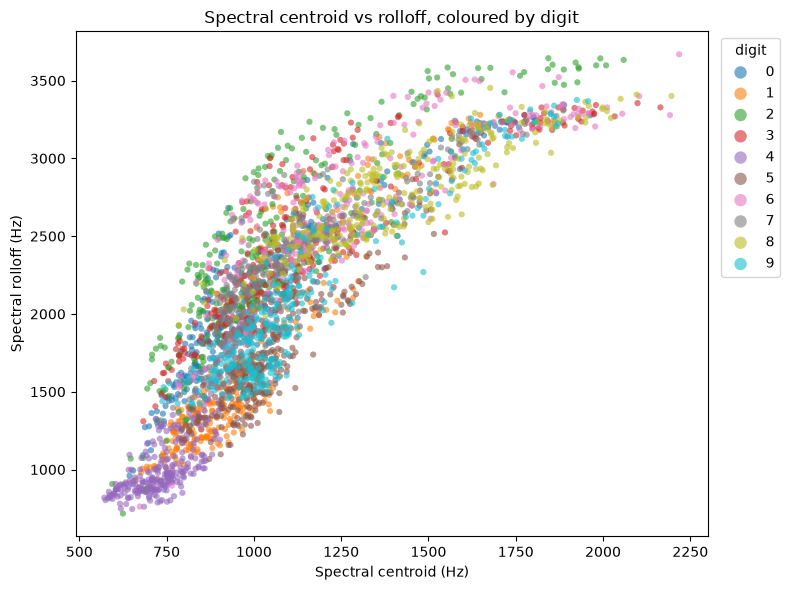

In [8]:
cmap = plt.get_cmap("tab10", 10)

fig, ax = plt.subplots(figsize=(8, 6))
for digit in range(10):
    mask = labels == digit
    ax.scatter(
        centroids[mask],
        rolloffs[mask],
        c=[cmap(digit)],
        label=str(digit),
        s=20,
        alpha=0.6,
        edgecolors="none",
    )
ax.set_xlabel("Spectral centroid (Hz)")
ax.set_ylabel("Spectral rolloff (Hz)")
ax.set_title("Spectral centroid vs rolloff, coloured by digit")
ax.legend(title="digit", bbox_to_anchor=(1.01, 1), loc="upper left", markerscale=2)
plt.tight_layout()
plt.show()

## Pair plots

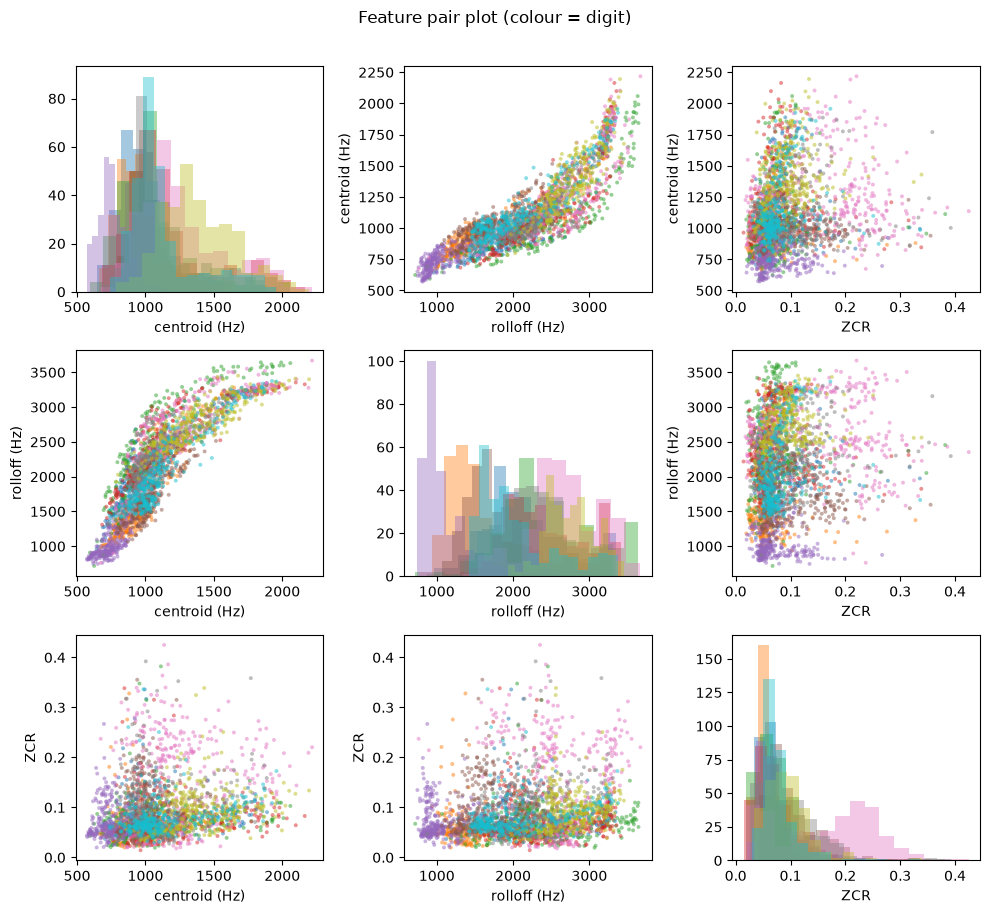

In [9]:
feature_names = ["centroid (Hz)", "rolloff (Hz)", "ZCR"]
features = [centroids, rolloffs, zcrs]

fig, axes = plt.subplots(3, 3, figsize=(10, 9))
for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        if i == j:
            for digit in range(10):
                mask = labels == digit
                ax.hist(features[i][mask], bins=15, alpha=0.4, color=cmap(digit))
            ax.set_xlabel(feature_names[i])
        else:
            for digit in range(10):
                mask = labels == digit
                ax.scatter(
                    features[j][mask],
                    features[i][mask],
                    c=[cmap(digit)],
                    s=8,
                    alpha=0.5,
                    edgecolors="none",
                )
            ax.set_xlabel(feature_names[j])
            ax.set_ylabel(feature_names[i])
plt.suptitle("Feature pair plot (colour = digit)", y=1.01)
plt.tight_layout()
plt.show()

## k-NN classifier

We use a simple k-nearest-neighbours classifier (k=5).
We test two variants:
- only the 3 extracted features
- adding the full spectrum

In [10]:
# Normalise features to zero mean and unit variance
X_mean, X_std = X.mean(axis=0), X.std(axis=0)
X_norm = (X - X_mean) / (X_std + 1e-8)

X_train, X_test, y_train, y_test = train_test_split(
    X_norm, labels, test_size=0.2, random_state=0, stratify=labels
)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

train_acc = knn.score(X_train, y_train)
test_acc = knn.score(X_test, y_test)
print(f"Train accuracy: {train_acc:.1%}")
print(f"Test  accuracy: {test_acc:.1%}  (chance = 10%)")

Train accuracy: 63.8%
Test  accuracy: 49.8%  (chance = 10%)


In [11]:
# add whole spectrum for each signal
mags = []
for clip in clips:
    mag = np.abs(np.fft.rfft(clip))
    mag = np.log(
        mag + 1
    )  # log-magnitude spectrum. We add 1 so that low magnitude values become 0 instead of -inf
    mags.append(mag)

X_more = np.hstack([X, np.vstack(mags)])

# Normalise features to zero mean and unit variance
X_mean_more, X_std = X_more.mean(axis=0), X_more.std(axis=0)
X_norm = (X_more - X_mean_more) / (X_std + 1e-8)

X_train, X_test, y_train, y_test = train_test_split(
    X_norm, labels, test_size=0.2, random_state=0, stratify=labels
)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

train_acc = knn.score(X_train, y_train)
test_acc = knn.score(X_test, y_test)
print(f"Train accuracy: {train_acc:.1%}")
print(f"Test  accuracy: {test_acc:.1%}  (chance = 10%)")

Train accuracy: 92.9%
Test  accuracy: 88.0%  (chance = 10%)


## Confusion matrix

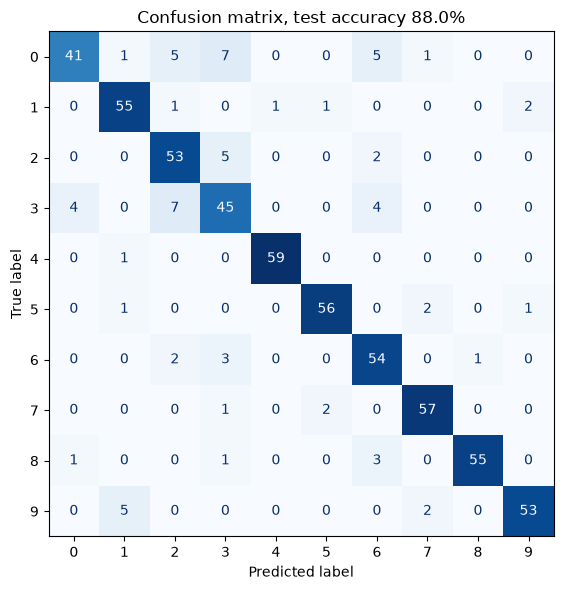

In [12]:
y_pred = knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion matrix, test accuracy {test_acc:.1%}")
plt.tight_layout()
plt.show()

## Does it generalise to a new speaker?

The split above is random over clips. Each of the six speakers recorded every digit 50 times, so almost every test clip has dozens of recordings of the same digit *by the same person* in the training set. A deployed system has to work for voices it has never heard.

**Leave-one-speaker-out** evaluation trains on five speakers and tests on the sixth, once for each speaker. The feature scaler is also fitted on the training data only.

**Before running the experiment**: what do you expect? will it generalize to new speakers? will it fail completely?

3 spectral features: random split 49.7%, held-out speaker 28.7% on average
3 features + log spectrum: random split 88.2%, held-out speaker 32.2% on average


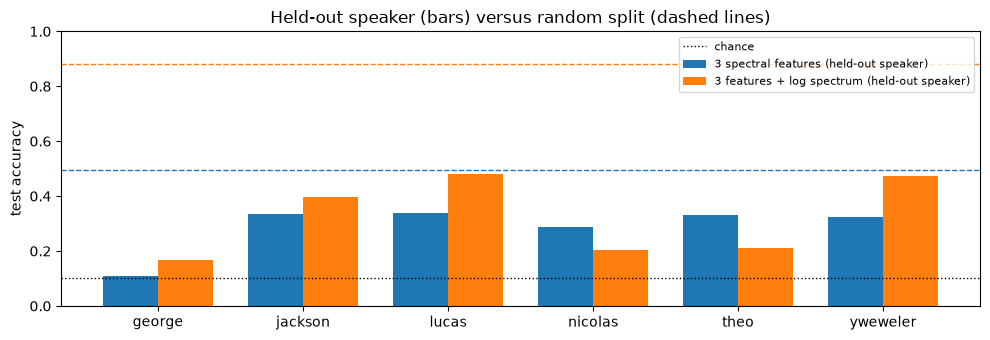

In [13]:
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

speaker_names = sorted(set(speakers))


def evaluate(features, name):
    """Random 80/20 split versus leave-one-speaker-out, same k-NN model."""
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
    X_tr, X_te, y_tr, y_te = train_test_split(
        features, labels, test_size=0.2, random_state=0, stratify=labels
    )
    random_acc = model.fit(X_tr, y_tr).score(X_te, y_te)
    # LeaveOneGroupOut orders folds by sorted group name, matching speaker_names
    per_speaker = cross_val_score(
        model, features, labels, groups=speakers, cv=LeaveOneGroupOut()
    )
    print(
        f"{name}: random split {random_acc:.1%}, held-out speaker {per_speaker.mean():.1%} on average"
    )
    return random_acc, per_speaker


results = {
    "3 spectral features": evaluate(X, "3 spectral features"),
    "3 features + log spectrum": evaluate(X_more, "3 features + log spectrum"),
}

fig, ax = plt.subplots(figsize=(10, 3.5))
width = 0.38
positions = np.arange(len(speaker_names))
for k, (name, (random_acc, per_speaker)) in enumerate(results.items()):
    bars = ax.bar(
        positions + (k - 0.5) * width,
        per_speaker,
        width,
        label=f"{name} (held-out speaker)",
    )
    ax.axhline(random_acc, color=bars[0].get_facecolor(), ls="--", lw=1)
ax.axhline(0.1, color="k", ls=":", lw=1, label="chance")
ax.set_xticks(positions, speaker_names)
ax.set(
    ylabel="test accuracy",
    ylim=(0, 1),
    title="Held-out speaker (bars) versus random split (dashed lines)",
)
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

**Interpretation**

- Are these results aligned with you expectation? How large is the gap, and is it the same for every speaker?
- Besides the digit, what else does the magnitude spectrum of a whole clip encode? Think about the voice (pitch, timbre), loudness, the microphone and the room.
- Why can k-NN exploit those cues on the random split but not when a speaker is held out?

# Exercise: generalize to new speakers

Design new features to add to the 1D feature vector for each clip to improve the **held-out speaker** accuracy of the k-NN model. Report the average over the six held-out speakers; the random split is shown only for comparison.

The baseline is the log-spectrum result printed above.You can reach around 60% using only NumPy and the ideas in the hints.

Since this is a hard exercise, feel free to use LLMs to brainstorm ideas or write part of the code. Just avoid using them to do all the thinking for you. The goal is to make you think about what kind of features we need to achieve speaker-invariance.

**Hints**

- Loudness differs between recordings and speakers. A gain multiplies the magnitude spectrum by a constant, which becomes an additive offset after the log. How can you remove it?
- Thousands of individual frequency bins make neighbours sensitive to small pitch differences. Averaging the power over a few tens of wider bands, spaced more densely at low frequencies, is more robust.
- The clips are padded with silence to one second. You can trim it first, then split the spoken part into a few consecutive pieces and compute band energies for each piece. This keeps some information about the *order* of the sounds, which the whole-clip spectrum throws away. Usually, models classifying sounds compute features on local fixed-size patches instead of the full clip.

The models here are not state-of-the-art, but they work well for their simplicity. More complex frequency-based features such as [MFCC](https://en.wikipedia.org/wiki/Mel-frequency_cepstrum) could bring it close to state-of-the-art.